# Speech Processing - Voice vs Non-Voice Analysis

This notebook performs:
1. Read/generate two `.wav` files (voice & non-voice)
2. Frame the signals
3. Calculate the number of frames
4. Display the first 20 frames for both signals
5. Apply Hamming & Hanning windows on the frames
6. Calculate Zero Crossing Rate and Energy for every frame
7. Plot ZCR and Energy for both files

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import get_window
import os

%matplotlib inline

---
## Step 1: Generate Sample `.wav` Files (Voice & Non-Voice)

In [2]:
def generate_voice_wav(filename="voice.wav", sr=16000, duration=2.0):
    """Generate a synthetic voiced signal (sum of harmonics simulating speech)."""
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    f0 = 150  # fundamental frequency ~150 Hz (typical voiced speech)
    signal = (
        0.6 * np.sin(2 * np.pi * f0 * t) +
        0.3 * np.sin(2 * np.pi * 2 * f0 * t) +
        0.15 * np.sin(2 * np.pi * 3 * f0 * t) +
        0.08 * np.sin(2 * np.pi * 4 * f0 * t)
    )
    # Add amplitude modulation to simulate syllable-like envelope
    envelope = 0.5 * (1 + np.sin(2 * np.pi * 3 * t))
    signal = signal * envelope
    # Add slight noise
    signal += 0.02 * np.random.randn(len(signal))
    # Normalize to int16
    signal = signal / np.max(np.abs(signal))
    signal_int16 = np.int16(signal * 32767)
    wavfile.write(filename, sr, signal_int16)
    print(f"[OK] Created '{filename}' - SR={sr}, Duration={duration}s")
    return filename


def generate_nonvoice_wav(filename="non_voice.wav", sr=16000, duration=2.0):
    """Generate a non-voice signal (white noise with some tonal bursts)."""
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    # White noise
    signal = 0.5 * np.random.randn(len(t))
    # Add some high-frequency tonal clicks
    for start in np.arange(0.2, duration, 0.4):
        idx_start = int(start * sr)
        idx_end = min(int((start + 0.02) * sr), len(t))
        signal[idx_start:idx_end] += 0.3 * np.sin(2 * np.pi * 4000 * t[idx_start:idx_end])
    # Normalize
    signal = signal / np.max(np.abs(signal))
    signal_int16 = np.int16(signal * 32767)
    wavfile.write(filename, sr, signal_int16)
    print(f"[OK] Created '{filename}' - SR={sr}, Duration={duration}s")
    return filename

In [3]:
# Generate the two .wav files
voice_file = generate_voice_wav("voice.wav")
nonvoice_file = generate_nonvoice_wav("non_voice.wav")

[OK] Created 'voice.wav' - SR=16000, Duration=2.0s
[OK] Created 'non_voice.wav' - SR=16000, Duration=2.0s


---
## Step 2: Read the `.wav` Files

In [4]:
def read_wav(filepath):
    """Read a .wav file and return sample rate and normalized float signal."""
    sr, data = wavfile.read(filepath)
    # Convert to mono if stereo
    if data.ndim > 1:
        data = data.mean(axis=1)
    # Normalize to float [-1, 1]
    signal = data.astype(np.float64) / np.max(np.abs(data))
    print(f"[OK] Read '{filepath}' - SR={sr}, Samples={len(signal)}, Duration={len(signal)/sr:.2f}s")
    return sr, signal

In [5]:
sr_v, signal_v = read_wav(voice_file)
sr_nv, signal_nv = read_wav(nonvoice_file)

[OK] Read 'voice.wav' - SR=16000, Samples=32000, Duration=2.00s
[OK] Read 'non_voice.wav' - SR=16000, Samples=32000, Duration=2.00s


---
## Step 3: Framing & Calculate Number of Frames

In [6]:
def frame_signal(signal, sr, frame_duration_ms=25, frame_shift_ms=10):
    """
    Divide signal into overlapping frames.
    
    Parameters:
        signal: 1D numpy array
        sr: sample rate
        frame_duration_ms: frame length in milliseconds
        frame_shift_ms: frame shift (hop) in milliseconds
    
    Returns:
        frames: 2D array (num_frames x frame_length)
        frame_length: number of samples per frame
        num_frames: total number of frames
    """
    frame_length = int(sr * frame_duration_ms / 1000)  # samples per frame
    frame_shift = int(sr * frame_shift_ms / 1000)      # samples per hop

    # Pad signal to ensure all samples are covered
    num_frames = max(1, 1 + (len(signal) - frame_length) // frame_shift)
    padded_length = (num_frames - 1) * frame_shift + frame_length
    padded_signal = np.zeros(padded_length)
    copy_len = min(len(signal), padded_length)
    padded_signal[:copy_len] = signal[:copy_len]

    # Create frame indices
    indices = (
        np.arange(frame_length)[np.newaxis, :] +
        np.arange(num_frames)[:, np.newaxis] * frame_shift
    )
    frames = padded_signal[indices]

    print(f"    Frame duration : {frame_duration_ms} ms ({frame_length} samples)")
    print(f"    Frame shift    : {frame_shift_ms} ms ({frame_shift} samples)")
    print(f"    Number of frames: {num_frames}")
    return frames, frame_length, num_frames

In [7]:
print("[Voice Signal]")
frames_v, fl_v, nf_v = frame_signal(signal_v, sr_v, frame_duration_ms=25, frame_shift_ms=10)

print("\n[Non-Voice Signal]")
frames_nv, fl_nv, nf_nv = frame_signal(signal_nv, sr_nv, frame_duration_ms=25, frame_shift_ms=10)

[Voice Signal]
    Frame duration : 25 ms (400 samples)
    Frame shift    : 10 ms (160 samples)
    Number of frames: 198

[Non-Voice Signal]
    Frame duration : 25 ms (400 samples)
    Frame shift    : 10 ms (160 samples)
    Number of frames: 198


---
## Step 4: Display the First 20 Frames

In [8]:
def display_frames(frames, n=20, label="Signal"):
    """Plot the first n frames."""
    n = min(n, len(frames))
    fig, axes = plt.subplots(4, 5, figsize=(18, 10))
    fig.suptitle(f"First {n} Frames - {label}", fontsize=16, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.plot(frames[i], linewidth=0.8, color='#2196F3' if 'Voice' in label else '#FF5722')
            ax.set_title(f"Frame {i+1}", fontsize=9)
            ax.set_xlabel("Sample", fontsize=7)
            ax.set_ylabel("Amplitude", fontsize=7)
            ax.tick_params(labelsize=7)
        else:
            ax.axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

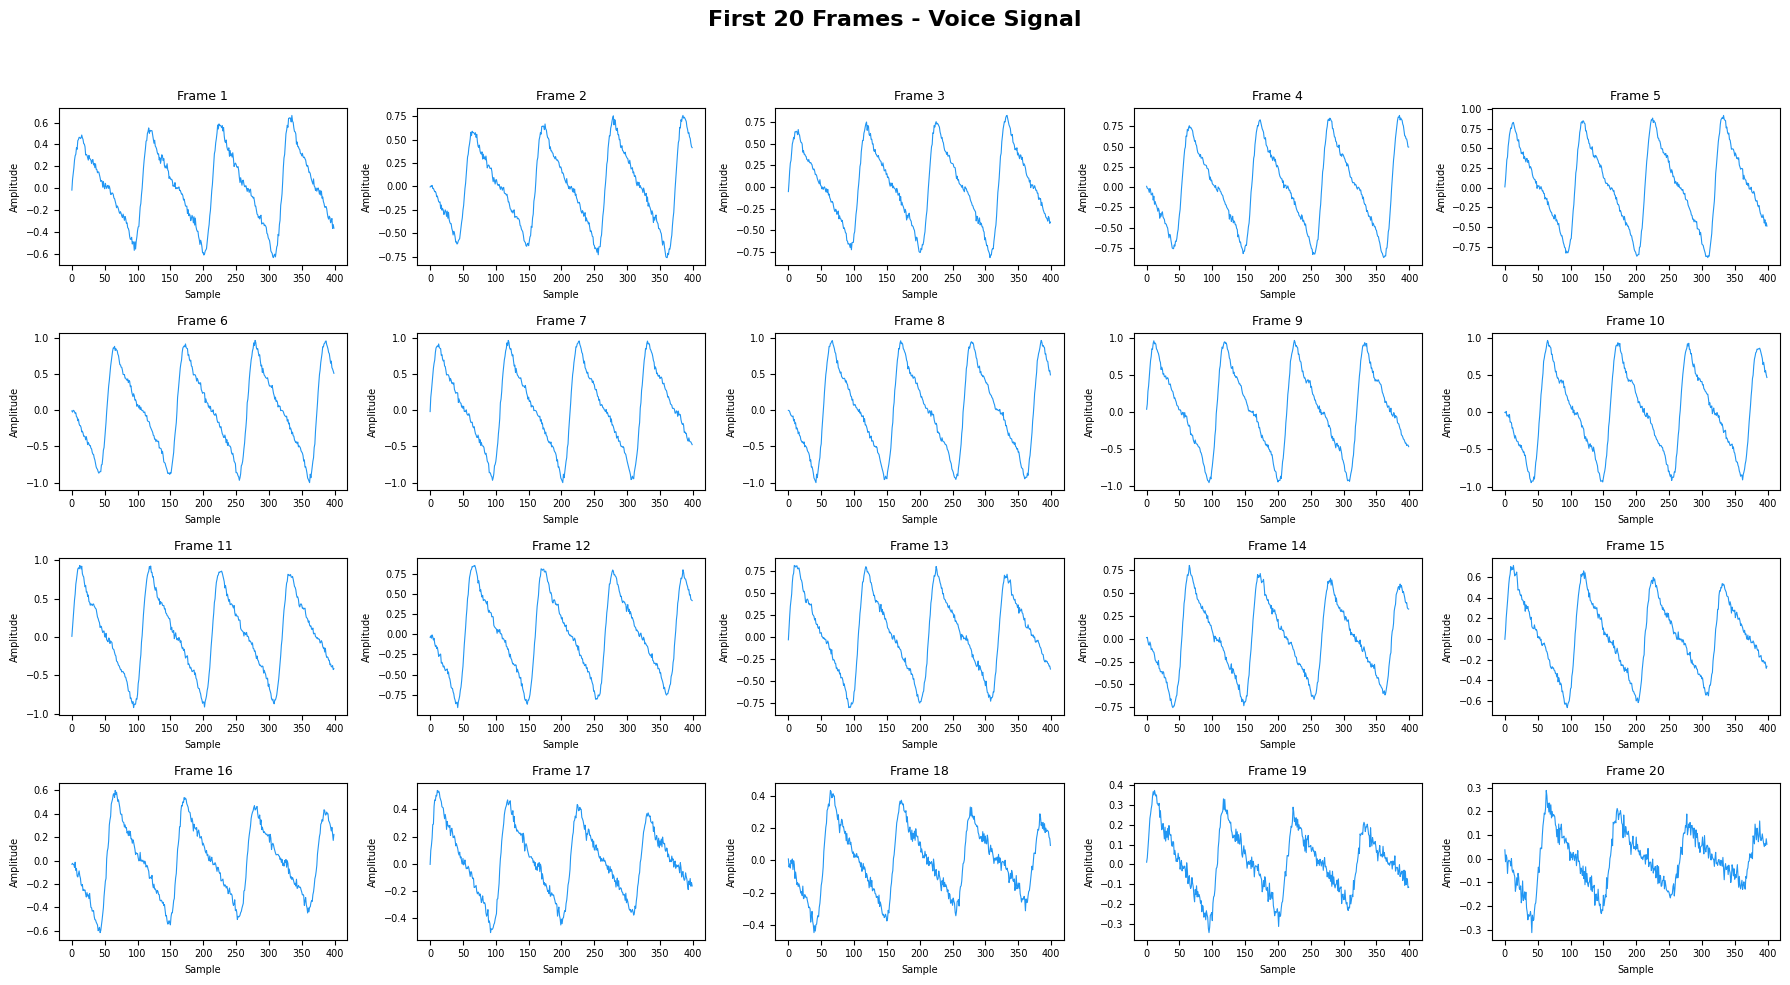

In [9]:
# First 20 frames - Voice Signal
display_frames(frames_v, n=20, label="Voice Signal")

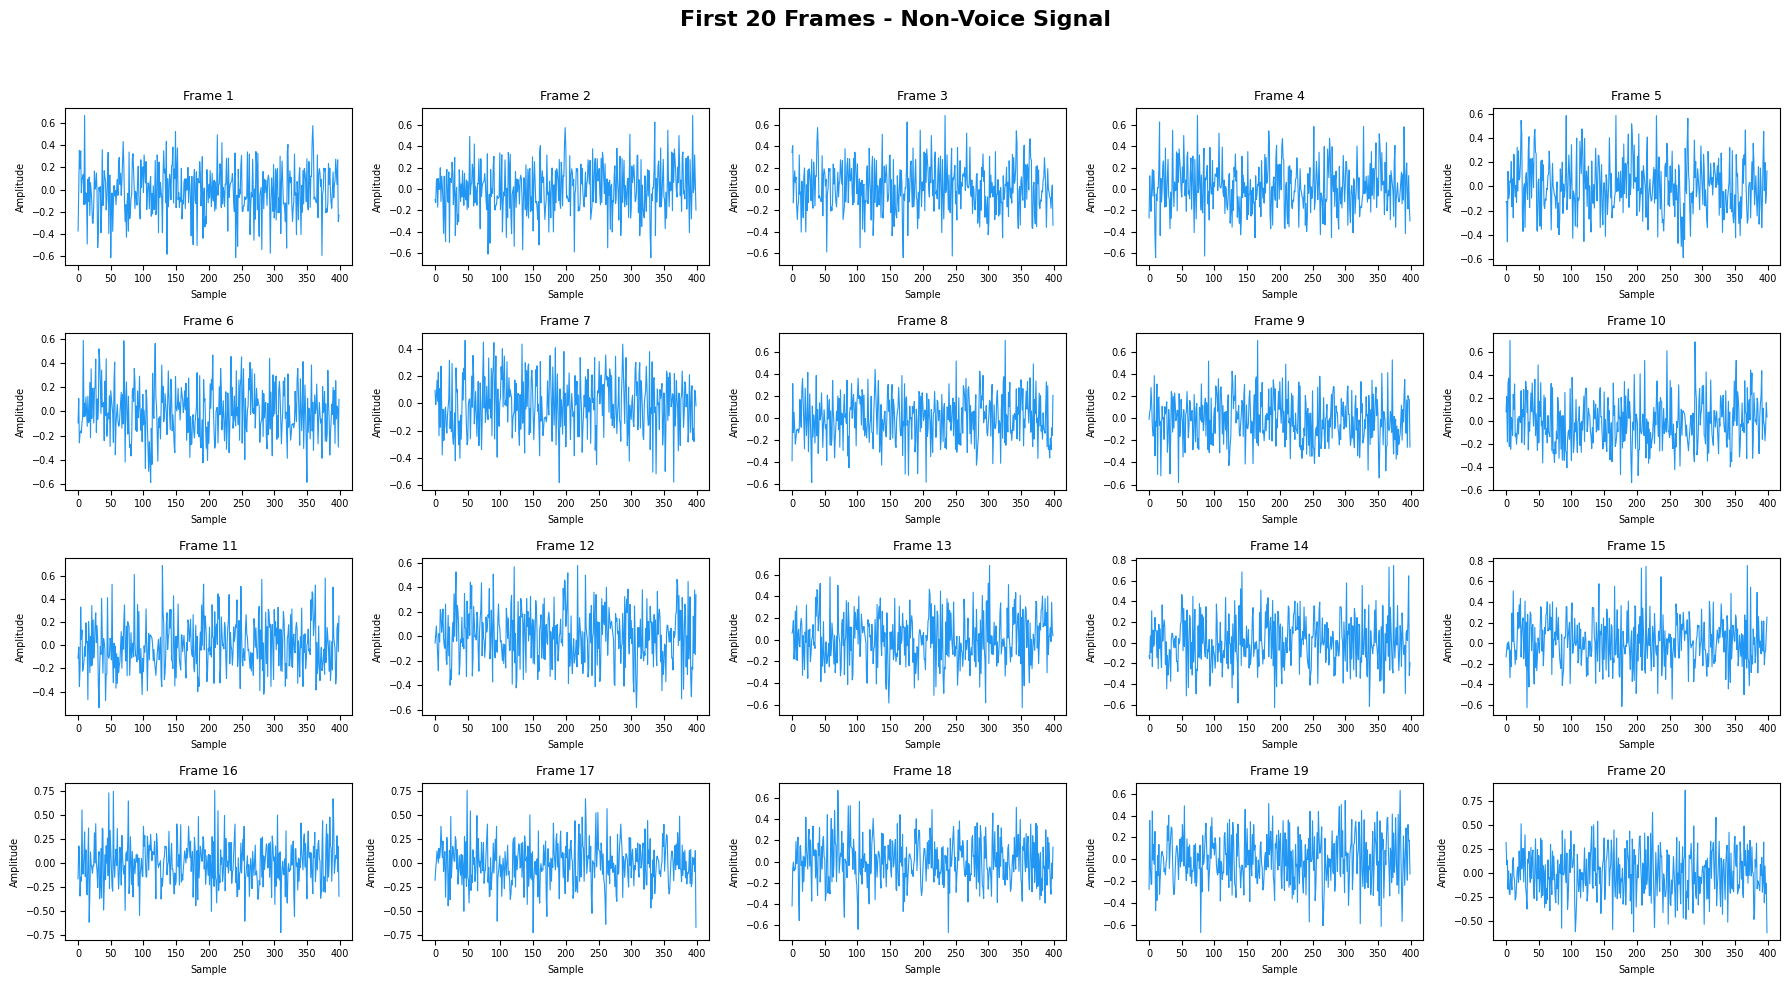

In [10]:
# First 20 frames - Non-Voice Signal
display_frames(frames_nv, n=20, label="Non-Voice Signal")

---
## Step 5: Apply Hamming & Hanning Windows

In [11]:
def apply_window(frames, frame_length, window_type='hamming'):
    """Apply a window function to each frame."""
    window = get_window(window_type, frame_length)
    windowed_frames = frames * window[np.newaxis, :]
    return windowed_frames

### Visualize Hamming vs Hanning Window Functions

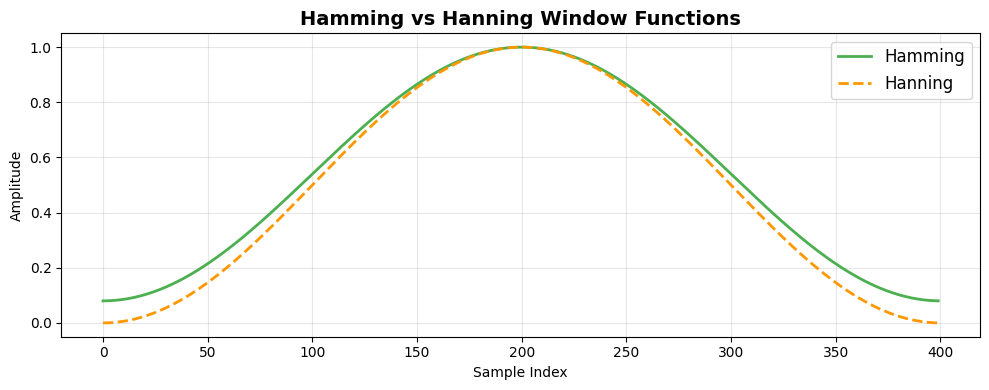

In [12]:
# Plot Hamming vs Hanning window
hamming_win = get_window('hamming', fl_v)
hanning_win = get_window('hann', fl_v)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hamming_win, label='Hamming', linewidth=2, color='#4CAF50')
ax.plot(hanning_win, label='Hanning', linewidth=2, color='#FF9800', linestyle='--')
ax.set_title("Hamming vs Hanning Window Functions", fontsize=14, fontweight='bold')
ax.set_xlabel("Sample Index")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Apply Hamming & Hanning Windows to Both Signals

In [13]:
# Hamming window
windowed_v_hamming = apply_window(frames_v, fl_v, 'hamming')
windowed_nv_hamming = apply_window(frames_nv, fl_nv, 'hamming')
print("[OK] Applied Hamming window to both signals")

# Hanning window
windowed_v_hanning = apply_window(frames_v, fl_v, 'hann')
windowed_nv_hanning = apply_window(frames_nv, fl_nv, 'hann')
print("[OK] Applied Hanning window to both signals")

[OK] Applied Hamming window to both signals
[OK] Applied Hanning window to both signals


### Compare Original vs Hamming Windowed Frames

In [14]:
def display_windowed_frames(frames, windowed_frames, n=4, label="Signal", window_type="Hamming"):
    """Compare original vs windowed frames."""
    n = min(n, len(frames))
    fig, axes = plt.subplots(n, 2, figsize=(14, 3 * n))
    fig.suptitle(f"{label} - Original vs {window_type} Windowed Frames", fontsize=14, fontweight='bold')
    for i in range(n):
        axes[i, 0].plot(frames[i], color='#2196F3', linewidth=0.8)
        axes[i, 0].set_title(f"Frame {i+1} (Original)", fontsize=9)
        axes[i, 0].set_ylabel("Amplitude", fontsize=8)
        axes[i, 1].plot(windowed_frames[i], color='#E91E63', linewidth=0.8)
        axes[i, 1].set_title(f"Frame {i+1} ({window_type})", fontsize=9)
        axes[i, 1].set_ylabel("Amplitude", fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("Sample")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

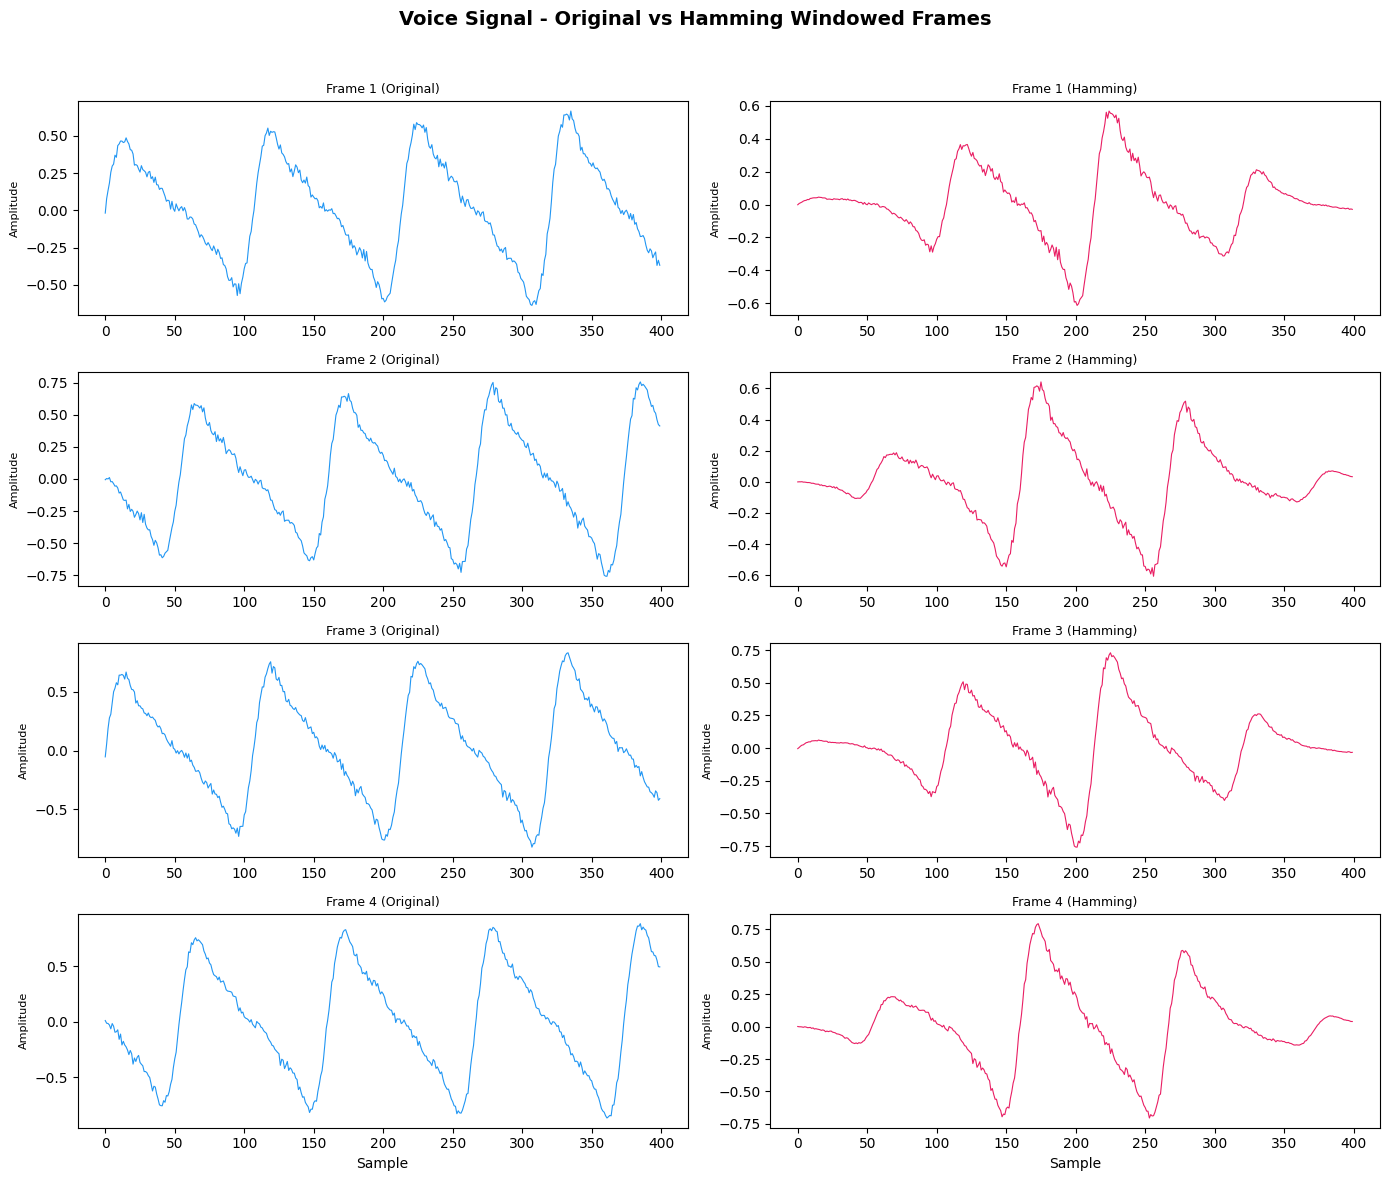

In [15]:
# Voice Signal: Original vs Hamming
display_windowed_frames(frames_v, windowed_v_hamming, n=4, label="Voice Signal", window_type="Hamming")

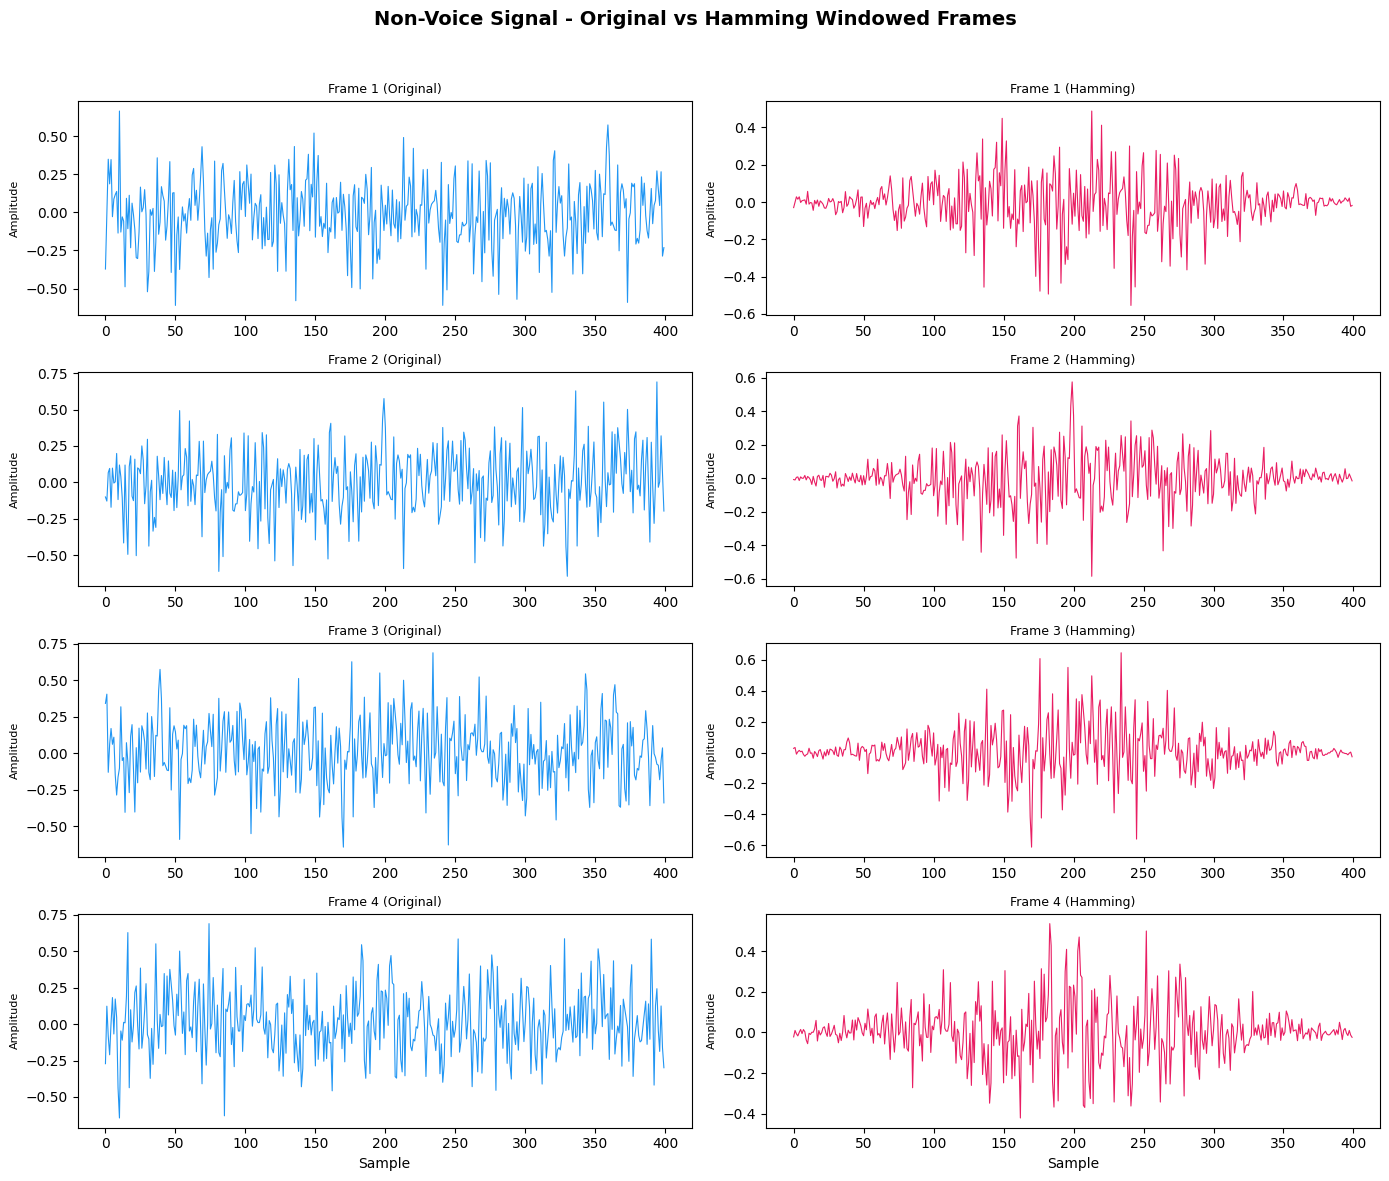

In [16]:
# Non-Voice Signal: Original vs Hamming
display_windowed_frames(frames_nv, windowed_nv_hamming, n=4, label="Non-Voice Signal", window_type="Hamming")

---
## Step 6: Calculate Zero Crossing Rate (ZCR) & Short-Time Energy (STE)

In [17]:
def zero_crossing_rate(frames):
    """Calculate zero crossing rate for each frame."""
    signs = np.sign(frames)
    # Count sign changes
    zcr = np.sum(np.abs(np.diff(signs, axis=1)), axis=1) / (2 * frames.shape[1])
    return zcr


def short_time_energy(frames):
    """Calculate short-time energy for each frame."""
    energy = np.sum(frames ** 2, axis=1) / frames.shape[1]
    return energy

In [18]:
# Calculate ZCR and Energy on Hamming-windowed frames
zcr_v = zero_crossing_rate(windowed_v_hamming)
zcr_nv = zero_crossing_rate(windowed_nv_hamming)
energy_v = short_time_energy(windowed_v_hamming)
energy_nv = short_time_energy(windowed_nv_hamming)

print(f"Voice    - Mean ZCR: {zcr_v.mean():.4f}, Mean Energy: {energy_v.mean():.6f}")
print(f"NonVoice - Mean ZCR: {zcr_nv.mean():.4f}, Mean Energy: {energy_nv.mean():.6f}")

Voice    - Mean ZCR: 0.1191, Mean Energy: 0.045424
NonVoice - Mean ZCR: 0.4966, Mean Energy: 0.019418


---
## Step 7: Plot ZCR & Energy for Both Signals

### Zero Crossing Rate (ZCR) Comparison

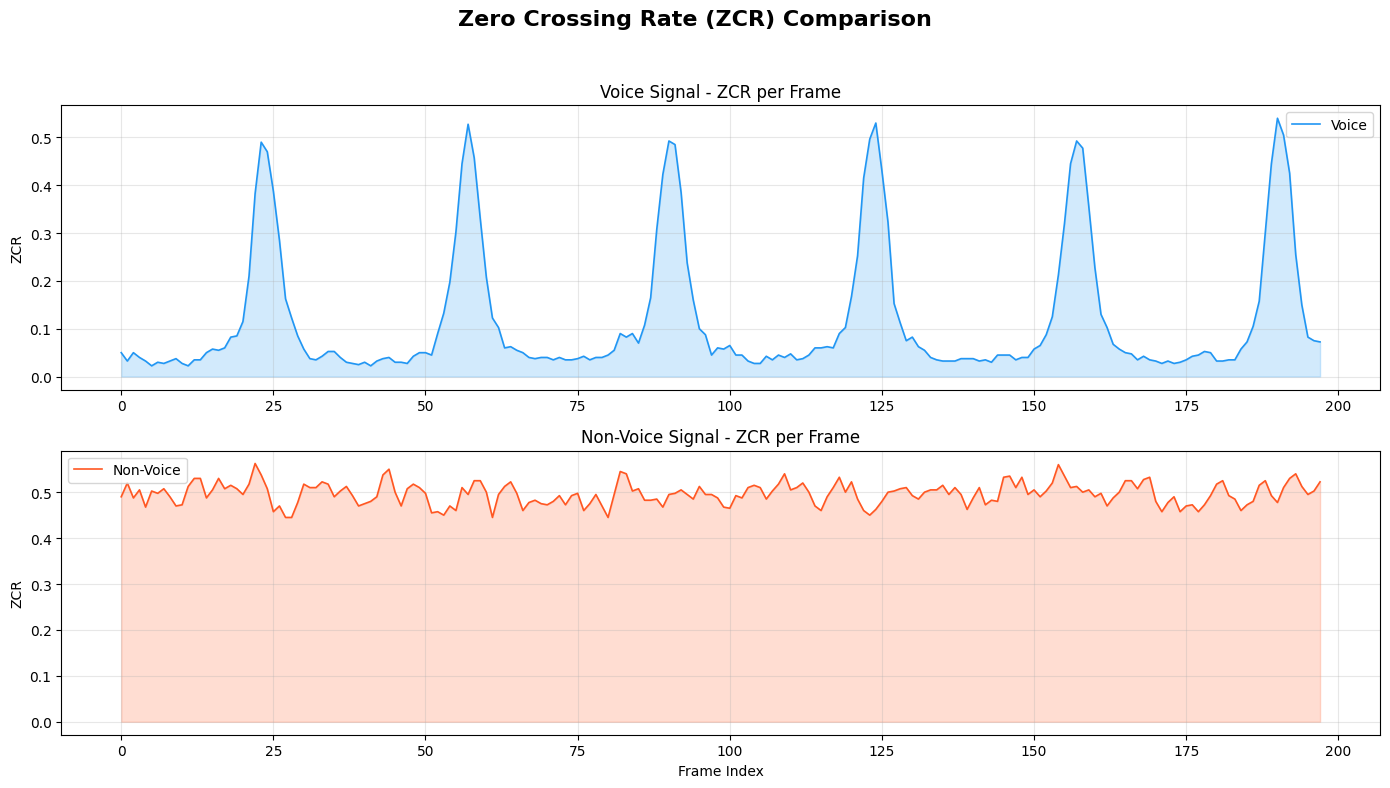

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
fig.suptitle("Zero Crossing Rate (ZCR) Comparison", fontsize=16, fontweight='bold')

axes[0].plot(zcr_v, color='#2196F3', linewidth=1.2, label='Voice')
axes[0].fill_between(range(len(zcr_v)), zcr_v, alpha=0.2, color='#2196F3')
axes[0].set_title("Voice Signal - ZCR per Frame", fontsize=12)
axes[0].set_ylabel("ZCR")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(zcr_nv, color='#FF5722', linewidth=1.2, label='Non-Voice')
axes[1].fill_between(range(len(zcr_nv)), zcr_nv, alpha=0.2, color='#FF5722')
axes[1].set_title("Non-Voice Signal - ZCR per Frame", fontsize=12)
axes[1].set_xlabel("Frame Index")
axes[1].set_ylabel("ZCR")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Short-Time Energy (STE) Comparison

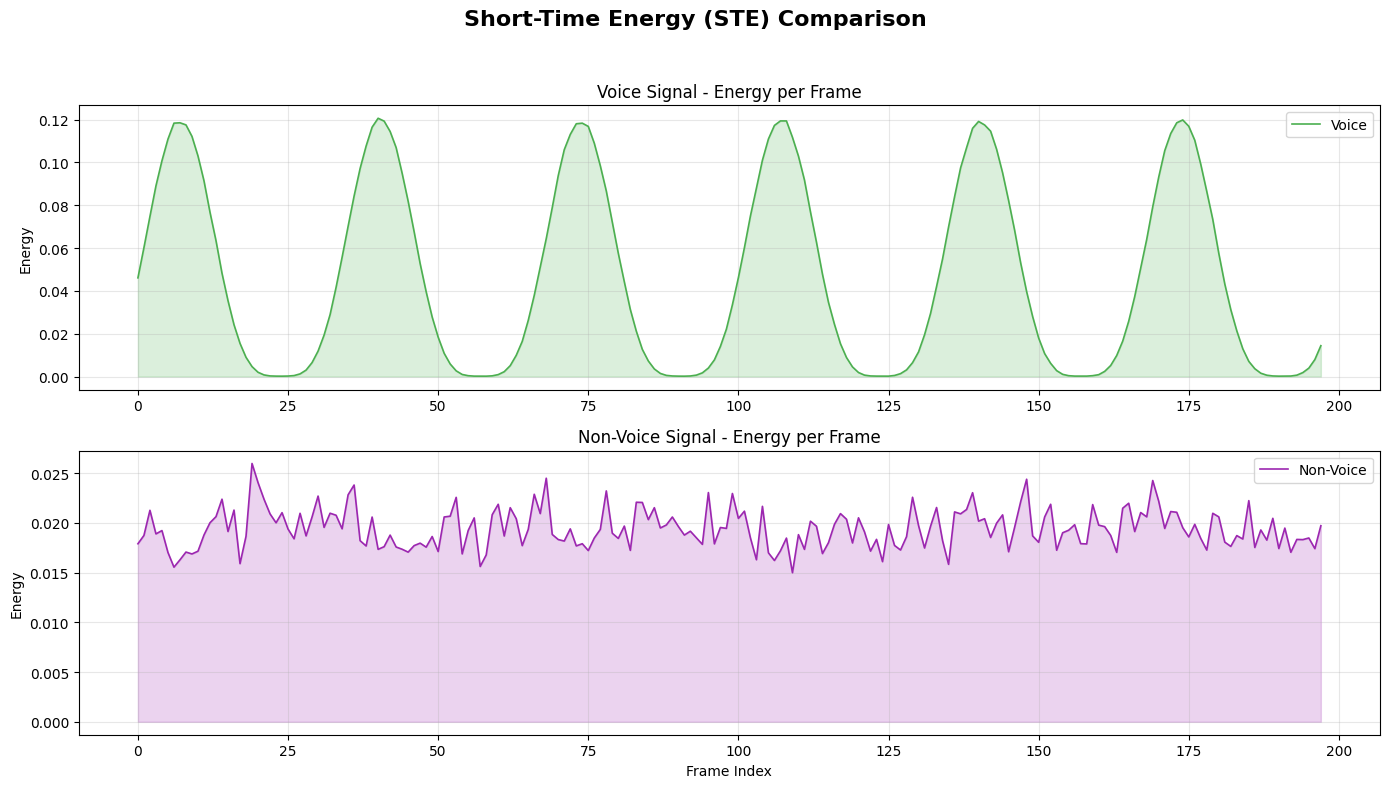

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
fig.suptitle("Short-Time Energy (STE) Comparison", fontsize=16, fontweight='bold')

axes[0].plot(energy_v, color='#4CAF50', linewidth=1.2, label='Voice')
axes[0].fill_between(range(len(energy_v)), energy_v, alpha=0.2, color='#4CAF50')
axes[0].set_title("Voice Signal - Energy per Frame", fontsize=12)
axes[0].set_ylabel("Energy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(energy_nv, color='#9C27B0', linewidth=1.2, label='Non-Voice')
axes[1].fill_between(range(len(energy_nv)), energy_nv, alpha=0.2, color='#9C27B0')
axes[1].set_title("Non-Voice Signal - Energy per Frame", fontsize=12)
axes[1].set_xlabel("Frame Index")
axes[1].set_ylabel("Energy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Combined Overlay Comparison

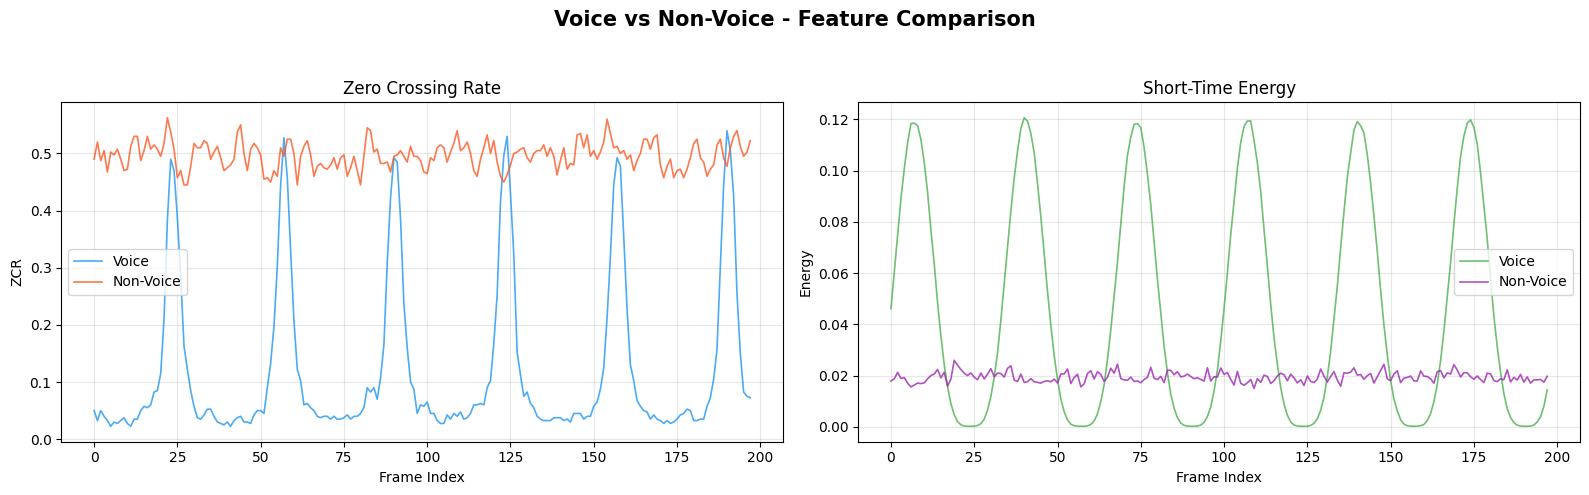

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Voice vs Non-Voice - Feature Comparison", fontsize=15, fontweight='bold')

# ZCR overlay
axes[0].plot(zcr_v, color='#2196F3', linewidth=1.2, label='Voice', alpha=0.8)
axes[0].plot(zcr_nv, color='#FF5722', linewidth=1.2, label='Non-Voice', alpha=0.8)
axes[0].set_title("Zero Crossing Rate", fontsize=12)
axes[0].set_xlabel("Frame Index")
axes[0].set_ylabel("ZCR")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Energy overlay
axes[1].plot(energy_v, color='#4CAF50', linewidth=1.2, label='Voice', alpha=0.8)
axes[1].plot(energy_nv, color='#9C27B0', linewidth=1.2, label='Non-Voice', alpha=0.8)
axes[1].set_title("Short-Time Energy", fontsize=12)
axes[1].set_xlabel("Frame Index")
axes[1].set_ylabel("Energy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

---
## Summary

| Feature | Voice Signal | Non-Voice Signal |
|---------|-------------|------------------|
| **ZCR** | Low (~0.12) - periodic structure | High (~0.49) - random noise |
| **Energy** | High peaks with periodicity | Low, flat energy |

**Key Observations:**
- **Voiced signals** have low zero crossing rates due to their periodic harmonic structure, and high energy concentrated in periodic bursts.
- **Non-voiced (noise) signals** have high zero crossing rates due to random sign changes, and relatively low, uniform energy distribution.